In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=100,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

In [ ]:
from torchvision.models import resnet18

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

model = resnet18(weights=None)
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(in_features, 10)
).to(device)

Using device: cuda


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

Epoch [1/50]  Loss: 1.7779   Acc: 33.20%
Epoch [2/50]  Loss: 1.4552   Acc: 46.83%
Epoch [3/50]  Loss: 1.3029   Acc: 52.77%
Epoch [4/50]  Loss: 1.1991   Acc: 57.32%
Epoch [5/50]  Loss: 1.1191   Acc: 60.41%
Epoch [6/50]  Loss: 0.9883   Acc: 64.88%
Epoch [7/50]  Loss: 0.9421   Acc: 66.61%
Epoch [8/50]  Loss: 0.9073   Acc: 67.83%
Epoch [9/50]  Loss: 0.8758   Acc: 69.20%
Epoch [10/50]  Loss: 0.8473   Acc: 70.21%
Epoch [11/50]  Loss: 0.7928   Acc: 71.87%
Epoch [12/50]  Loss: 0.7667   Acc: 72.98%
Epoch [13/50]  Loss: 0.7483   Acc: 73.75%
Epoch [14/50]  Loss: 0.7347   Acc: 74.21%
Epoch [15/50]  Loss: 0.7261   Acc: 74.48%
Epoch [16/50]  Loss: 0.6925   Acc: 75.65%
Epoch [17/50]  Loss: 0.6768   Acc: 75.93%
Epoch [18/50]  Loss: 0.6693   Acc: 76.24%
Epoch [19/50]  Loss: 0.6671   Acc: 76.42%
Epoch [20/50]  Loss: 0.6580   Acc: 76.83%
Epoch [21/50]  Loss: 0.6383   Acc: 77.48%
Epoch [22/50]  Loss: 0.6267   Acc: 77.69%
Epoch [23/50]  Loss: 0.6265   Acc: 77.66%
Epoch [24/50]  Loss: 0.6215   Acc: 78.12%
E

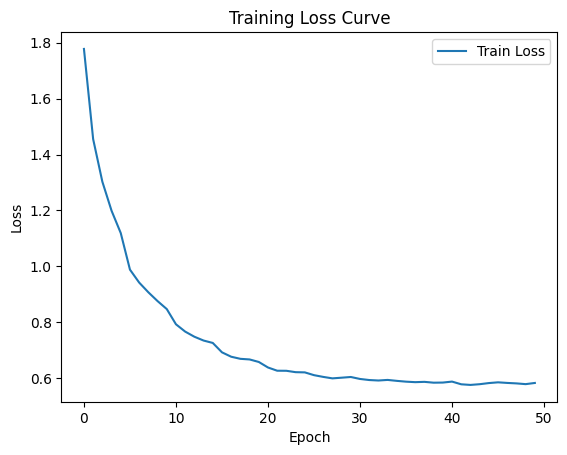

In [ ]:
#!pip install torchinfo

from torchinfo import summary
summary(model, input_size=(1, 3, 32, 32))

#from torchsummary import summary

#summary(model.cpu(), (3, 32, 32))
#model.to(device)


train_losses, test_accuracies = [], []
#total = 0
#correct = 0
epochs = 50

for epoch in range(epochs):
    running_loss = 0.0
    total = 0
    correct = 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        #for name, param in model.named_parameters():
         # print(name, param.shape)
        #break
        #print(images.shape)

        #summary(model)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        #scheduler.step()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        running_loss += loss.item()
        #train_losses.append(running_loss/len(trainloader))
    scheduler.step()

    epoch_loss = running_loss / len(trainloader)
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{epochs}]  Loss: {epoch_loss:.4f}   Acc: {epoch_acc:.2f}%")

print("Training complete.")
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.show()




Test Accuracy: 77.92%


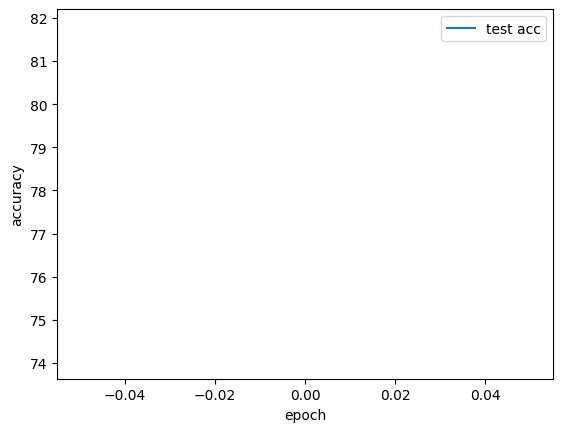

In [ ]:
test_accuracies = []
correct = 0
total = 0
model.eval()  # evaluation mode

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")
test_accuracies.append(100 * correct / total)

plt.plot(test_accuracies, label='test acc')
plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.legend(); plt.show()

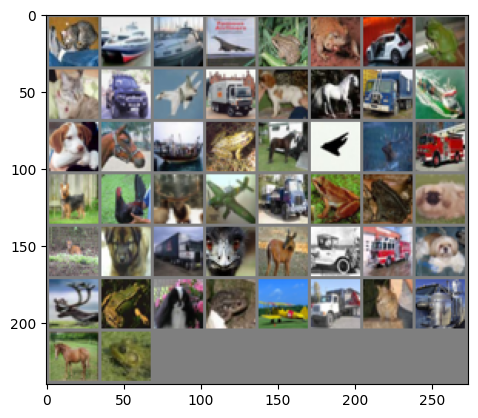

Predicted: cat   ship  ship  ship  frog  frog  dog   frog  cat   car   plane truck dog   horse truck ship  dog   horse ship  frog  horse plane plane truck deer  bird  deer  plane truck frog  frog  dog   bird  dog   truck car   deer  car   truck dog   deer  frog  horse frog  plane truck cat   truck horse frog 


In [ ]:
dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)
outputs = model(images)
_, predicted = torch.max(outputs, 1)

# unnormalize and plot
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.cpu().numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

imshow(torchvision.utils.make_grid(images[:50]))
print('Predicted:', ' '.join(f'{classes[predicted[j]]:5s}' for j in range(50)))